In [52]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [53]:
df = pd.read_csv("../data/CustomerDataset.csv")

In [54]:
df.head()

,Customer_ID,Age,Gender,City_Tier,Employment_Type,Customer_Segment,Tenure_Months,Monthly_Income,Account_Balance,Credit_Score,...,App_Usage_Hours_Last_3M,App_Usage_Hours_Previous_3M,App_Usage_Change_Pct,Last_Login_Days_Ago,Customer_Support_Calls,Complaints,Satisfaction_Score,Offers_Used,Balance_Change_Pct,Churn
0,C100001,61,Female,Tier 3,Salaried,Standard,38,54000,275100,628,...,4.6,4.9,-6.7,13,0,0,1,0,14.7,0
1,C100002,39,Male,Tier 3,Student,Standard,12,35000,172500,688,...,8.4,7.9,6.2,14,4,0,5,4,8.7,1
2,C100003,66,Female,Tier 1,Salaried,Standard,89,55300,298200,685,...,7.8,7.9,-1.0,9,1,0,7,1,-7.0,0
3,C100004,29,Female,Tier 3,Salaried,Standard,42,39500,137900,722,...,0.5,0.5,0.0,5,3,1,7,5,-22.8,0
4,C100005,62,Male,Tier 1,Salaried,High Value,34,86700,98800,632,...,8.1,6.9,18.2,8,3,0,10,2,4.0,0


In [55]:
df.shape

(10000, 28)

In [56]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 28 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   Customer_ID                  10000 non-null  str    
 1   Age                          10000 non-null  int64  
 2   Gender                       10000 non-null  str    
 3   City_Tier                    10000 non-null  str    
 4   Employment_Type              10000 non-null  str    
 5   Customer_Segment             10000 non-null  str    
 6   Tenure_Months                10000 non-null  int64  
 7   Monthly_Income               10000 non-null  int64  
 8   Account_Balance              10000 non-null  int64  
 9   Credit_Score                 10000 non-null  int64  
 10  Product_Type                 10000 non-null  str    
 11  Products_Used                10000 non-null  int64  
 12  Preferred_Channel            10000 non-null  str    
 13  Loyalty_Member              

In [57]:
df.isnull().sum()

Customer_ID                    0
Age                            0
Gender                         0
City_Tier                      0
Employment_Type                0
Customer_Segment               0
Tenure_Months                  0
Monthly_Income                 0
Account_Balance                0
Credit_Score                   0
Product_Type                   0
Products_Used                  0
Preferred_Channel              0
Loyalty_Member                 0
Transactions_Last_3M           0
Transactions_Previous_3M       0
Transaction_Change_Pct         0
Avg_Transaction_Value          0
App_Usage_Hours_Last_3M        0
App_Usage_Hours_Previous_3M    0
App_Usage_Change_Pct           0
Last_Login_Days_Ago            0
Customer_Support_Calls         0
Complaints                     0
Satisfaction_Score             0
Offers_Used                    0
Balance_Change_Pct             0
Churn                          0
dtype: int64

In [58]:
df["Churn"].value_counts()

Churn
0    9426
1     574
Name: count, dtype: int64

In [59]:
df["Churn"].value_counts(normalize=True) * 100

Churn
0    94.26
1     5.74
Name: proportion, dtype: float64

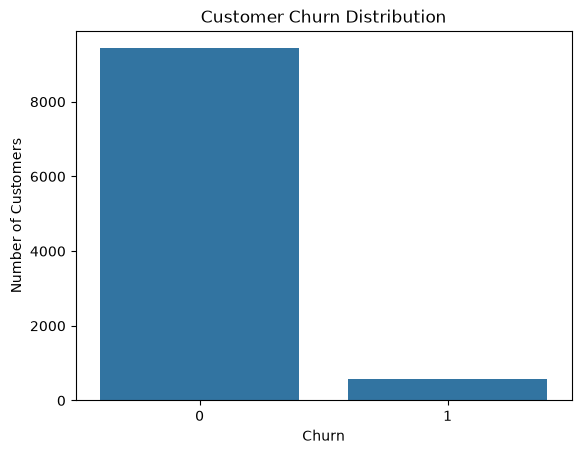

In [60]:
sns.countplot(data=df, x="Churn")

plt.title("Customer Churn Distribution")
plt.xlabel("Churn")
plt.ylabel("Number of Customers")

plt.show()

In [61]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
Age,10000.0,43.95200,15.331354,18.0,31.00,44.0,57.000,70.0
Tenure_Months,10000.0,48.20860,27.881833,1.0,24.00,48.0,72.000,96.0
Monthly_Income,10000.0,55775.91000,28081.080524,12000.0,36100.00,50000.0,68225.000,300000.0
Account_Balance,10000.0,222438.61000,169192.277823,7400.0,98275.00,185950.0,300800.000,2229800.0
Credit_Score,10000.0,709.60840,54.833792,527.0,672.00,709.0,747.000,850.0
Products_Used,10000.0,2.54110,1.098650,1.0,2.00,2.0,3.000,5.0
Transactions_Last_3M,10000.0,28.87920,7.972162,6.0,23.00,28.0,34.000,70.0
Transactions_Previous_3M,10000.0,30.00040,5.442404,12.0,26.00,30.0,34.000,53.0
Transaction_Change_Pct,10000.0,-3.71528,19.817572,-76.5,-17.20,-3.6,10.000,62.5
Avg_Transaction_Value,10000.0,3023.46950,1090.033893,100.0,2288.75,3023.5,3743.000,7345.0


In [62]:
numerical_columns = df.select_dtypes(include=["int64", "float64"]).columns

categorical_columns = df.select_dtypes(include=["object"]).columns

print("Numerical columns:")
print(numerical_columns)

print("\nCategorical columns:")
print(categorical_columns)

Numerical columns:
Index(['Age', 'Tenure_Months', 'Monthly_Income', 'Account_Balance',
       'Credit_Score', 'Products_Used', 'Transactions_Last_3M',
       'Transactions_Previous_3M', 'Transaction_Change_Pct',
       'Avg_Transaction_Value', 'App_Usage_Hours_Last_3M',
       'App_Usage_Hours_Previous_3M', 'App_Usage_Change_Pct',
       'Last_Login_Days_Ago', 'Customer_Support_Calls', 'Complaints',
       'Satisfaction_Score', 'Offers_Used', 'Balance_Change_Pct', 'Churn'],
      dtype='str')

Categorical columns:
Index(['Customer_ID', 'Gender', 'City_Tier', 'Employment_Type',
       'Customer_Segment', 'Product_Type', 'Preferred_Channel',
       'Loyalty_Member'],
      dtype='str')


C:\Users\vedan\AppData\Local\Temp\ipykernel_2248\3453752714.py:3: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_columns = df.select_dtypes(include=["object"]).columns


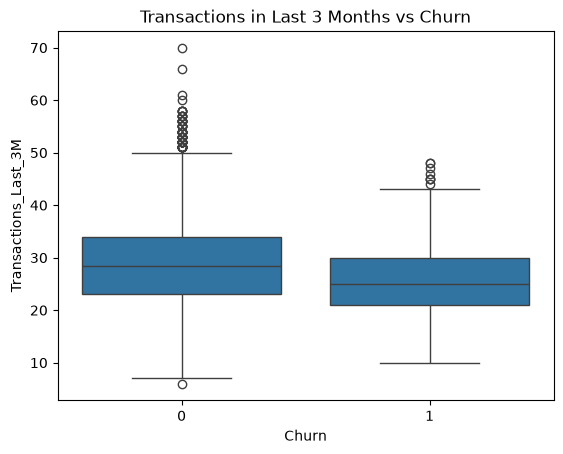

In [63]:
sns.boxplot(data=df, x="Churn", y="Transactions_Last_3M")

plt.title("Transactions in Last 3 Months vs Churn")
plt.show()

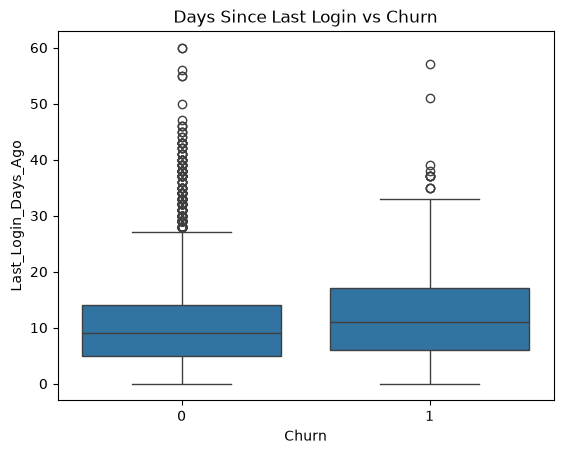

In [64]:
sns.boxplot(data=df, x="Churn", y="Last_Login_Days_Ago")

plt.title("Days Since Last Login vs Churn")
plt.show()

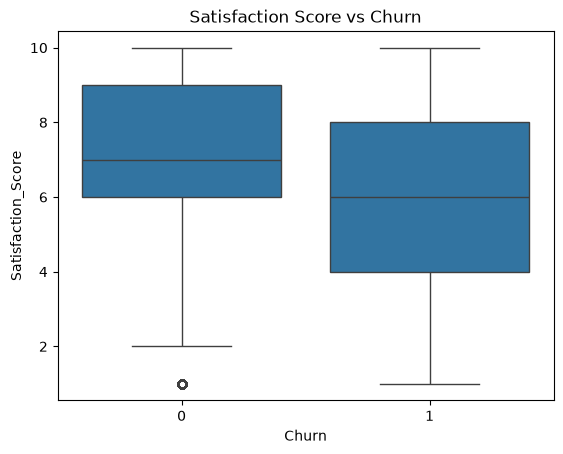

In [65]:
sns.boxplot(data=df, x="Churn", y="Satisfaction_Score")

plt.title("Satisfaction Score vs Churn")
plt.show()

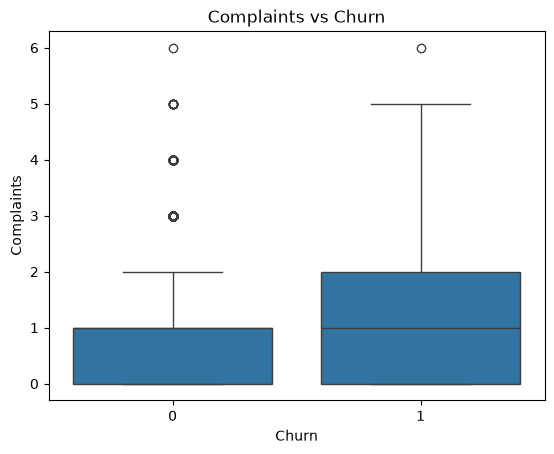

In [66]:
sns.boxplot(data=df, x="Churn", y="Complaints")

plt.title("Complaints vs Churn")
plt.show()

In [67]:
correlation = df.select_dtypes(include=["int64", "float64"]).corr()

correlation["Churn"].sort_values(ascending=False)

Churn                          1.000000
Complaints                     0.073147
Last_Login_Days_Ago            0.054199
Customer_Support_Calls         0.053481
Credit_Score                   0.014362
Offers_Used                    0.008588
Age                           -0.000798
Account_Balance               -0.009003
Avg_Transaction_Value         -0.013658
Monthly_Income                -0.025201
Balance_Change_Pct            -0.027005
Products_Used                 -0.030364
Transactions_Previous_3M      -0.031854
App_Usage_Hours_Previous_3M   -0.044684
App_Usage_Hours_Last_3M       -0.067054
Tenure_Months                 -0.085468
App_Usage_Change_Pct          -0.085714
Satisfaction_Score            -0.101649
Transactions_Last_3M          -0.104497
Transaction_Change_Pct        -0.112309
Name: Churn, dtype: float64

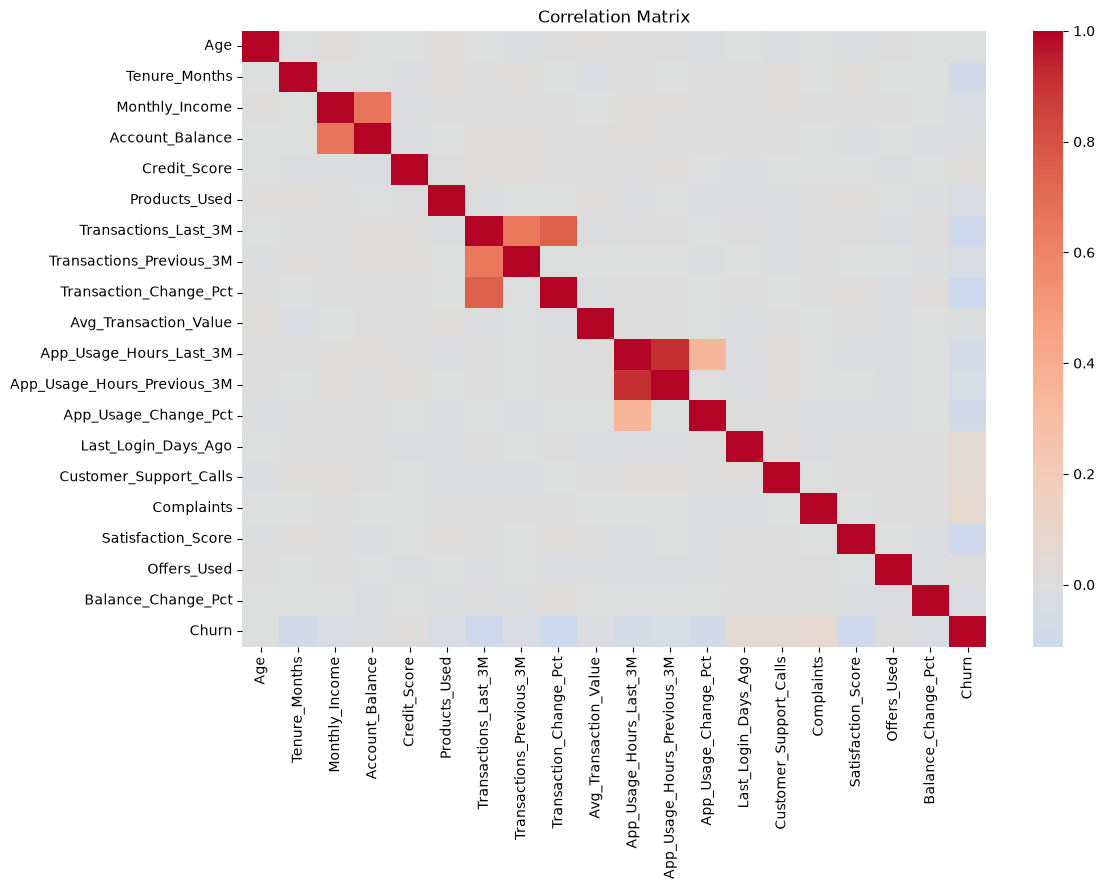

In [68]:
plt.figure(figsize=(12, 8))

sns.heatmap(
    correlation,
    cmap="coolwarm",
    center=0
)

plt.title("Correlation Matrix")
plt.show()

In [69]:
pd.crosstab(
    df["Customer_Segment"],
    df["Churn"],
    normalize="index"
) * 100

Churn,0,1
Customer_Segment,,
Basic,93.107477,6.892523
Emerging,90.140845,9.859155
High Value,95.604396,4.395604
Standard,94.600972,5.399028


In [70]:
pd.crosstab(
    df["Product_Type"],
    df["Churn"],
    normalize="index"
) * 100

Churn,0,1
Product_Type,,
Current,94.196199,5.803801
Premium,93.700000,6.300000
Salary,94.730539,5.269461
Savings,94.151275,5.848725


In [71]:
pd.crosstab(
    df["Preferred_Channel"],
    df["Churn"],
    normalize="index"
) * 100

Churn,0,1
Preferred_Channel,,
ATM,95.209581,4.790419
Branch,93.608653,6.391347
Mobile App,94.282723,5.717277
Phone,94.515306,5.484694
Web,93.924612,6.075388


In [72]:
X = df.drop(columns=["Churn", "Customer_ID"])
y = df["Churn"]

In [73]:
print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (10000, 26)
y shape: (10000,)


In [74]:
numerical_features = X.select_dtypes(
    include=["int64", "float64"]
).columns.tolist()

categorical_features = X.select_dtypes(
    include=["object"]
).columns.tolist()

print("Numerical features:")
print(numerical_features)

print("\nCategorical features:")
print(categorical_features)

Numerical features:
['Age', 'Tenure_Months', 'Monthly_Income', 'Account_Balance', 'Credit_Score', 'Products_Used', 'Transactions_Last_3M', 'Transactions_Previous_3M', 'Transaction_Change_Pct', 'Avg_Transaction_Value', 'App_Usage_Hours_Last_3M', 'App_Usage_Hours_Previous_3M', 'App_Usage_Change_Pct', 'Last_Login_Days_Ago', 'Customer_Support_Calls', 'Complaints', 'Satisfaction_Score', 'Offers_Used', 'Balance_Change_Pct']

Categorical features:
['Gender', 'City_Tier', 'Employment_Type', 'Customer_Segment', 'Product_Type', 'Preferred_Channel', 'Loyalty_Member']


C:\Users\vedan\AppData\Local\Temp\ipykernel_2248\1998881318.py:5: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_features = X.select_dtypes(


In [75]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [76]:
print("Training:")
print(y_train.value_counts(normalize=True))

print("\nTesting:")
print(y_test.value_counts(normalize=True))

Training:
Churn
0    0.942625
1    0.057375
Name: proportion, dtype: float64

Testing:
Churn
0    0.9425
1    0.0575
Name: proportion, dtype: float64


In [77]:
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer

In [78]:
preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), numerical_features),
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_features)
    ]
)

In [79]:
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression

logistic_model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("classifier", LogisticRegression(
            class_weight="balanced",
            max_iter=1000,
            random_state=42
        ))
    ]
)

In [80]:
logistic_model.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocessor', ...), ('classifier', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[int64](2,)","[0,1]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](26,)","['Age','Gender','City_Tier',...,'Satisfaction_Score','Offers_Used', 'Balance_Change_Pct']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,26
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainde

In [81]:
y_pred = logistic_model.predict(X_test)

In [82]:
y_probability = logistic_model.predict_proba(X_test)[:, 1]

In [83]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report
)

In [84]:
print("Accuracy:", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))
print("Recall:", recall_score(y_test, y_pred))
print("F1 Score:", f1_score(y_test, y_pred))
print("ROC-AUC:", roc_auc_score(y_test, y_probability))

Accuracy: 0.708
Precision: 0.12359550561797752
Recall: 0.6695652173913044
F1 Score: 0.2086720867208672
ROC-AUC: 0.7666751239764733


In [85]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.97      0.71      0.82      1885
           1       0.12      0.67      0.21       115

    accuracy                           0.71      2000
   macro avg       0.55      0.69      0.51      2000
weighted avg       0.92      0.71      0.79      2000



In [86]:
cm = confusion_matrix(y_test, y_pred)

print(cm)

[[1339  546]
 [  38   77]]


In [87]:
from sklearn.tree import DecisionTreeClassifier

In [88]:
decision_tree_model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("classifier", DecisionTreeClassifier(
            class_weight="balanced",
            random_state=42
        ))
    ]
)

In [89]:
decision_tree_model.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocessor', ...), ('classifier', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[int64](2,)","[0,1]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](26,)","['Age','Gender','City_Tier',...,'Satisfaction_Score','Offers_Used', 'Balance_Change_Pct']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,26
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainde

In [90]:
y_pred_dt = decision_tree_model.predict(X_test)

In [91]:
y_probability_dt = decision_tree_model.predict_proba(X_test)[:, 1]

In [92]:
print("Accuracy:", accuracy_score(y_test, y_pred_dt))
print("Precision:", precision_score(y_test, y_pred_dt))
print("Recall:", recall_score(y_test, y_pred_dt))
print("F1 Score:", f1_score(y_test, y_pred_dt))
print("ROC-AUC:", roc_auc_score(y_test, y_probability_dt))

Accuracy: 0.9035
Precision: 0.1388888888888889
Recall: 0.13043478260869565
F1 Score: 0.13452914798206278
ROC-AUC: 0.5405489562910851


In [93]:
print(classification_report(y_test, y_pred_dt))

              precision    recall  f1-score   support

           0       0.95      0.95      0.95      1885
           1       0.14      0.13      0.13       115

    accuracy                           0.90      2000
   macro avg       0.54      0.54      0.54      2000
weighted avg       0.90      0.90      0.90      2000



In [94]:
cm_dt = confusion_matrix(y_test, y_pred_dt)

print(cm_dt)

[[1792   93]
 [ 100   15]]


In [95]:
from sklearn.ensemble import RandomForestClassifier

In [96]:
random_forest_model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("classifier", RandomForestClassifier(
            n_estimators=100,
            class_weight="balanced",
            random_state=42
        ))
    ]
)

In [97]:
random_forest_model.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocessor', ...), ('classifier', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[int64](2,)","[0,1]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](26,)","['Age','Gender','City_Tier',...,'Satisfaction_Score','Offers_Used', 'Balance_Change_Pct']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,26
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainde

In [98]:
y_pred_rf = random_forest_model.predict(X_test)

In [99]:
y_probability_rf = random_forest_model.predict_proba(X_test)[:, 1]

In [100]:
print("Accuracy:", accuracy_score(y_test, y_pred_rf))
print("Precision:", precision_score(y_test, y_pred_rf))
print("Recall:", recall_score(y_test, y_pred_rf))
print("F1 Score:", f1_score(y_test, y_pred_rf))
print("ROC-AUC:", roc_auc_score(y_test, y_probability_rf))

Accuracy: 0.9425
Precision: 0.0
Recall: 0.0
F1 Score: 0.0
ROC-AUC: 0.7240410563948795


c:\Users\vedan\miniconda3\Lib\site-packages\sklearn\metrics\_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


In [101]:
print(classification_report(y_test, y_pred_rf))

              precision    recall  f1-score   support

           0       0.94      1.00      0.97      1885
           1       0.00      0.00      0.00       115

    accuracy                           0.94      2000
   macro avg       0.47      0.50      0.49      2000
weighted avg       0.89      0.94      0.91      2000



c:\Users\vedan\miniconda3\Lib\site-packages\sklearn\metrics\_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\vedan\miniconda3\Lib\site-packages\sklearn\metrics\_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\vedan\miniconda3\Lib\site-packages\sklearn\metrics\_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


In [102]:
cm_rf = confusion_matrix(y_test, y_pred_rf)

print(cm_rf)

[[1885    0]
 [ 115    0]]


In [103]:
print(y_probability_rf[:20])

[0.11 0.01 0.06 0.16 0.07 0.03 0.14 0.15 0.06 0.04 0.31 0.11 0.12 0.04
 0.13 0.09 0.04 0.05 0.15 0.2 ]


In [104]:
print("Maximum probability:", y_probability_rf.max())
print("Minimum probability:", y_probability_rf.min())

Maximum probability: 0.48
Minimum probability: 0.0


In [105]:
print(pd.Series(y_probability_rf).describe())

count    2000.000000
mean        0.119180
std         0.076996
min         0.000000
25%         0.060000
50%         0.100000
75%         0.160000
max         0.480000
dtype: float64


In [106]:
from sklearn.metrics import precision_score, recall_score, f1_score

thresholds = [0.5, 0.4, 0.3, 0.2, 0.1]

for threshold in thresholds:
    predictions = (y_probability_rf >= threshold).astype(int)

    precision = precision_score(y_test, predictions, zero_division=0)
    recall = recall_score(y_test, predictions, zero_division=0)
    f1 = f1_score(y_test, predictions, zero_division=0)

    print(f"Threshold: {threshold}")
    print(f"Precision: {precision:.3f}")
    print(f"Recall: {recall:.3f}")
    print(f"F1: {f1:.3f}")
    print("-" * 30)

Threshold: 0.5
Precision: 0.000
Recall: 0.000
F1: 0.000
------------------------------
Threshold: 0.4
Precision: 0.571
Recall: 0.035
F1: 0.066
------------------------------
Threshold: 0.3
Precision: 0.221
Recall: 0.130
F1: 0.164
------------------------------
Threshold: 0.2
Precision: 0.155
Recall: 0.417
F1: 0.226
------------------------------
Threshold: 0.1
Precision: 0.085
Recall: 0.809
F1: 0.153
------------------------------


In [107]:
from sklearn.model_selection import GridSearchCV

In [108]:
rf_pipeline = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("classifier", RandomForestClassifier(
            class_weight="balanced",
            random_state=42
        ))
    ]
)

In [109]:
param_grid = {
    "classifier__n_estimators": [100, 200],
    "classifier__max_depth": [5, 10, 15],
    "classifier__min_samples_split": [2, 5],
    "classifier__min_samples_leaf": [1, 2, 5]
}

In [110]:
grid_search = GridSearchCV(
    estimator=rf_pipeline,
    param_grid=param_grid,
    scoring="f1",
    cv=5,
    n_jobs=-1,
    verbose=1
)

In [111]:
grid_search.fit(X_train, y_train)

Fitting 5 folds for each of 36 candidates, totalling 180 fits


,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",Pipeline(step...m_state=42))])
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'classifier__max_depth': [5, 10, ...], 'classifier__min_samples_leaf': [1, 2, ...], 'classifier__min_samples_split': [2, 5], 'classifier__n_estimators': [100, 200]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'f1'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"verbose verbose: int, default=0Controls the verbosity of information printed during fitting, with highervalues yielding more detailed logging.- 0 : no messages are printed;- >=1 : summary of the total number of fits;- >=2 : computation time for each fold and parameter candidate;- >=3 : fold indices and scores;- >=10 : parameter candidate indices and START messages before each fit.",1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metri

In [112]:
print("Best parameters:")
print(grid_search.best_params_)

Best parameters:
{'classifier__max_depth': 10, 'classifier__min_samples_leaf': 5, 'classifier__min_samples_split': 2, 'classifier__n_estimators': 200}


In [113]:
print("Best CV F1 score:")
print(grid_search.best_score_)

Best CV F1 score:
0.21843235622424464


In [114]:
best_rf_model = grid_search.best_estimator_

In [115]:
y_pred_rf_tuned = best_rf_model.predict(X_test)

In [116]:
y_probability_rf_tuned = best_rf_model.predict_proba(X_test)[:, 1]

In [117]:
print("Accuracy:", accuracy_score(y_test, y_pred_rf_tuned))
print("Precision:", precision_score(y_test, y_pred_rf_tuned, zero_division=0))
print("Recall:", recall_score(y_test, y_pred_rf_tuned, zero_division=0))
print("F1 Score:", f1_score(y_test, y_pred_rf_tuned, zero_division=0))
print("ROC-AUC:", roc_auc_score(y_test, y_probability_rf_tuned))

Accuracy: 0.897
Precision: 0.22424242424242424
Recall: 0.3217391304347826
F1 Score: 0.2642857142857143
ROC-AUC: 0.7503263752739014


In [118]:
print(classification_report(
    y_test,
    y_pred_rf_tuned,
    zero_division=0
))

              precision    recall  f1-score   support

           0       0.96      0.93      0.94      1885
           1       0.22      0.32      0.26       115

    accuracy                           0.90      2000
   macro avg       0.59      0.63      0.60      2000
weighted avg       0.92      0.90      0.91      2000



In [119]:
cm_rf_tuned = confusion_matrix(y_test, y_pred_rf_tuned)

print(cm_rf_tuned)

[[1757  128]
 [  78   37]]


In [120]:
thresholds = [0.5, 0.4, 0.3, 0.2, 0.1]

for threshold in thresholds:
    predictions = (y_probability_rf_tuned >= threshold).astype(int)

    precision = precision_score(
        y_test,
        predictions,
        zero_division=0
    )

    recall = recall_score(
        y_test,
        predictions,
        zero_division=0
    )

    f1 = f1_score(
        y_test,
        predictions,
        zero_division=0
    )

    print(f"Threshold: {threshold}")
    print(f"Precision: {precision:.3f}")
    print(f"Recall: {recall:.3f}")
    print(f"F1: {f1:.3f}")
    print("-" * 30)

Threshold: 0.5
Precision: 0.224
Recall: 0.322
F1: 0.264
------------------------------
Threshold: 0.4
Precision: 0.136
Recall: 0.530
F1: 0.216
------------------------------
Threshold: 0.3
Precision: 0.097
Recall: 0.817
F1: 0.173
------------------------------
Threshold: 0.2
Precision: 0.070
Recall: 0.983
F1: 0.130
------------------------------
Threshold: 0.1
Precision: 0.058
Recall: 1.000
F1: 0.110
------------------------------


In [121]:
print(df.columns.tolist())

['Customer_ID', 'Age', 'Gender', 'City_Tier', 'Employment_Type', 'Customer_Segment', 'Tenure_Months', 'Monthly_Income', 'Account_Balance', 'Credit_Score', 'Product_Type', 'Products_Used', 'Preferred_Channel', 'Loyalty_Member', 'Transactions_Last_3M', 'Transactions_Previous_3M', 'Transaction_Change_Pct', 'Avg_Transaction_Value', 'App_Usage_Hours_Last_3M', 'App_Usage_Hours_Previous_3M', 'App_Usage_Change_Pct', 'Last_Login_Days_Ago', 'Customer_Support_Calls', 'Complaints', 'Satisfaction_Score', 'Offers_Used', 'Balance_Change_Pct', 'Churn']


In [122]:
print(df.dtypes)

Customer_ID                        str
Age                              int64
Gender                             str
City_Tier                          str
Employment_Type                    str
Customer_Segment                   str
Tenure_Months                    int64
Monthly_Income                   int64
Account_Balance                  int64
Credit_Score                     int64
Product_Type                       str
Products_Used                    int64
Preferred_Channel                  str
Loyalty_Member                     str
Transactions_Last_3M             int64
Transactions_Previous_3M         int64
Transaction_Change_Pct         float64
Avg_Transaction_Value            int64
App_Usage_Hours_Last_3M        float64
App_Usage_Hours_Previous_3M    float64
App_Usage_Change_Pct           float64
Last_Login_Days_Ago              int64
Customer_Support_Calls           int64
Complaints                       int64
Satisfaction_Score               int64
Offers_Used              

In [123]:
print(df.head())

  Customer_ID  Age  Gender City_Tier Employment_Type Customer_Segment  \
0     C100001   61  Female    Tier 3        Salaried         Standard   
1     C100002   39    Male    Tier 3         Student         Standard   
2     C100003   66  Female    Tier 1        Salaried         Standard   
3     C100004   29  Female    Tier 3        Salaried         Standard   
4     C100005   62    Male    Tier 1        Salaried       High Value   

   Tenure_Months  Monthly_Income  Account_Balance  Credit_Score  ...  \
0             38           54000           275100           628  ...   
1             12           35000           172500           688  ...   
2             89           55300           298200           685  ...   
3             42           39500           137900           722  ...   
4             34           86700            98800           632  ...   

  App_Usage_Hours_Last_3M  App_Usage_Hours_Previous_3M App_Usage_Change_Pct  \
0                     4.6                        